## I ran this notebook on a WSL ubuntu enviroment, so the dataset isnt accessible here. wanted to show results.

### going to train on 10% of the data as a demo

In [1]:
import sys, platform, torch
print(f"Python    : {sys.version.split()[0]}")
print(f"Platform  : {platform.platform()}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Python    : 3.11.15
Platform  : Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
PyTorch   : 2.2.2+cu121
CUDA avail: True
Device    : NVIDIA GeForce RTX 3060
VRAM      : 12.9 GB


### The SARdet 100k dataset uses COCO format for its annotations. yolov12 uses another format so I converted it (file in drive)

below is the dataset structure


=== Train ===
  Images       : 94,493
  Annotations  : 198,747
  Class counts :
    0 ship        93,373
    1 aircraft    40,705
    2 car         9,561
    3 tank        24,187
    4 bridge      27,615
    5 harbor      3,306

=== Val ===
  Images       : 10,492
  Annotations  : 22,703
  Class counts :
    0 ship        10,530
    1 aircraft    5,194
    2 car         1,222
    3 tank        2,035
    4 bridge      3,318
    5 harbor      404


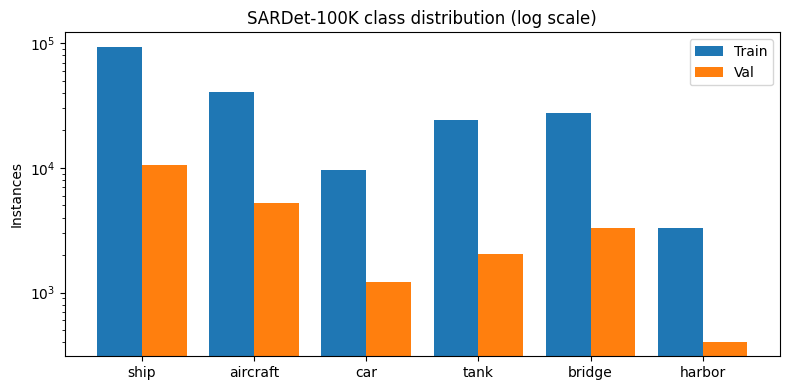

In [4]:
import json
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

DATA_ROOT = Path("/home/user/sar/datasets/SARDet_100K")
ANN_DIR = DATA_ROOT / "Annotations"

def summarize_split(name, json_path):
    with open(json_path) as f:
        d = json.load(f)
    cats = {c["id"]: c["name"] for c in d["categories"]}
    cls_counts = Counter(a["category_id"] for a in d["annotations"])
    print(f"\n=== {name} ===")
    print(f"  Images       : {len(d['images']):,}")
    print(f"  Annotations  : {len(d['annotations']):,}")
    print(f"  Class counts :")
    for cid in sorted(cats):
        print(f"    {cid} {cats[cid]:<10s}  {cls_counts.get(cid, 0):,}")
    return cats, cls_counts

train_cats, train_counts = summarize_split("Train", ANN_DIR / "train.json")
val_cats,   val_counts   = summarize_split("Val",   ANN_DIR / "val.json")

classes = [train_cats[i] for i in sorted(train_cats)]
train_vals = [train_counts.get(i, 0) for i in sorted(train_cats)]
val_vals   = [val_counts.get(i, 0)   for i in sorted(train_cats)]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(classes))
ax.bar([i - 0.2 for i in x], train_vals, width=0.4, label="Train")
ax.bar([i + 0.2 for i in x], val_vals,   width=0.4, label="Val")
ax.set_xticks(list(x))
ax.set_xticklabels(classes)
ax.set_ylabel("Instances")
ax.set_yscale("log")
ax.set_title("SARDet-100K class distribution (log scale)")
ax.legend()
plt.tight_layout()
plt.show()

## ground truth examples from the dataset (human-labled)

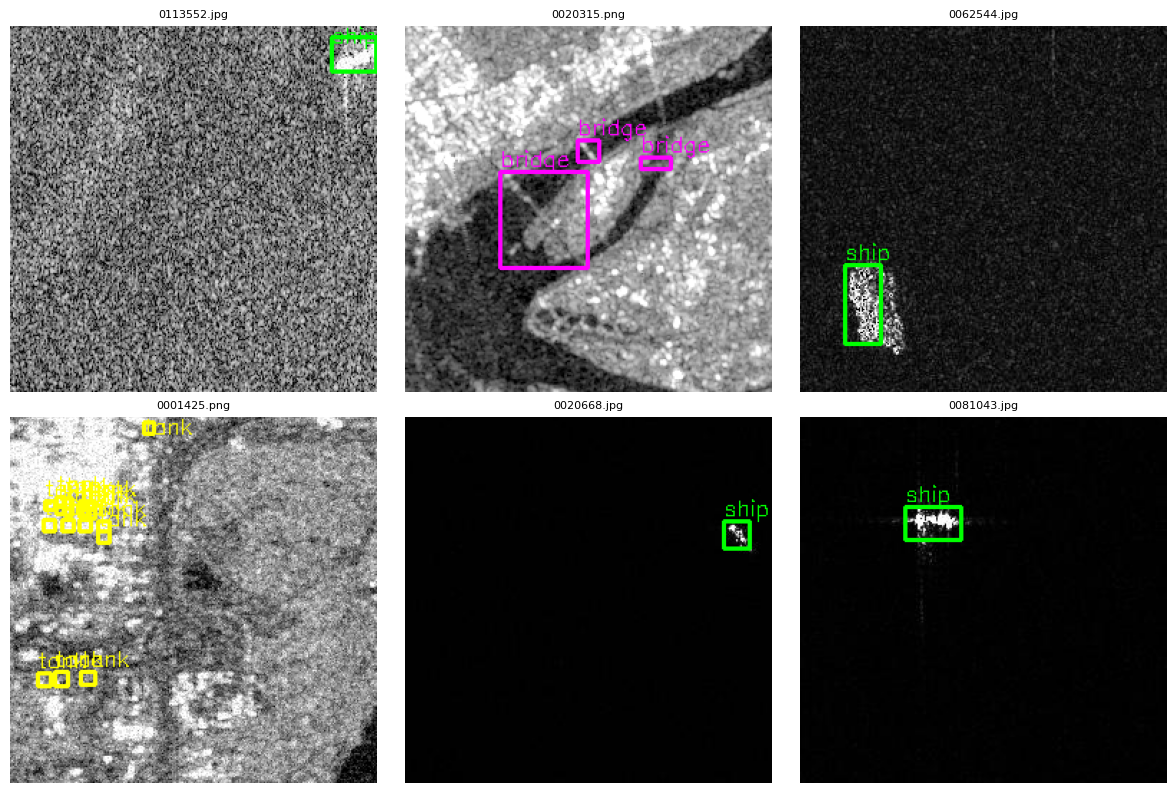

In [5]:
import random
import cv2
import numpy as np

VAL_IMG_DIR = DATA_ROOT / "images" / "val"
VAL_LBL_DIR = DATA_ROOT / "labels" / "val"
CLASS_NAMES = ["ship", "aircraft", "car", "tank", "bridge", "harbor"]
COLORS = [(0, 255, 0), (255, 80, 80), (80, 80, 255),
          (255, 255, 0), (255, 0, 255), (0, 255, 255)]

random.seed(0)
sample_imgs = random.sample(list(VAL_IMG_DIR.iterdir()), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, img_path in zip(axes.flat, sample_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = VAL_LBL_DIR / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            cls, cx, cy, bw, bh = line.split()
            cls = int(cls)
            cx, cy, bw, bh = float(cx)*w, float(cy)*h, float(bw)*w, float(bh)*h
            x1, y1 = int(cx - bw/2), int(cy - bh/2)
            x2, y2 = int(cx + bw/2), int(cy + bh/2)
            cv2.rectangle(img, (x1, y1), (x2, y2), COLORS[cls], 2)
            cv2.putText(img, CLASS_NAMES[cls], (x1, max(y1-4, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORS[cls], 1)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

#Training

1 epoch since its just an examples, and image size is bad to save time

In [6]:
from ultralytics import YOLO

model = YOLO("yolov12n.yaml")
results = model.train(
    data="/home/user/sar/datasets/sardet.yaml",
    epochs=1,
    imgsz=320,
    batch=8,
    workers=2,
    device=0,
    fraction=0.1,
    project="/home/user/sar/runs",
    name="dryrun_10pct",
    exist_ok=True,
    verbose=True,
)

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.15 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.yaml, data=/home/user/sar/datasets/sardet.yaml, epochs=1, time=None, patience=100, batch=8, imgsz=320, save=True, save_period=-1, cache=False, device=0, workers=2, project=/home/user/sar/runs, name=dryrun_10pct, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=0.1, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_b

100%|██████████| 5.26M/5.26M [00:00<00:00, 6.11MB/s]


AMP: checks passed ✅


train: Scanning /home/user/sar/datasets/SARDet_100K/labels/train... 9449 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9449/9449 [00:12<00:00, 774.56it/s]


train: New cache created: /home/user/sar/datasets/SARDet_100K/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

Plotting labels to /home/user/sar/runs/dryrun_10pct/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 121 weight(decay=0.0), 128 weight(decay=0.0005), 127 bias(decay=0.0)
Image sizes 320 train, 320 val
Using 2 dataloader workers
Logging results to /home/user/sar/runs/dryrun_10pct
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1     0.765G      3.923       4.58      3.108          1        320: 100%|██████████| 1182/1182 [03:41<00:00,  5.34it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 656/656 [01:27<00:00,  7.47it/s]


                   all      10492      22695      0.743     0.0681     0.0482     0.0164

1 epochs completed in 0.087 hours.
Optimizer stripped from /home/user/sar/runs/dryrun_10pct/weights/last.pt, 5.4MB
Optimizer stripped from /home/user/sar/runs/dryrun_10pct/weights/best.pt, 5.4MB

Validating /home/user/sar/runs/dryrun_10pct/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.15 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLOv12n summary (fused): 376 layers, 2,509,514 parameters, 0 gradients, 5.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 656/656 [01:22<00:00,  7.96it/s]


                   all      10492      22695      0.743     0.0681     0.0482     0.0164
                  ship       6441      10528      0.304      0.351      0.239     0.0815
              aircraft       1972       5193      0.154     0.0572     0.0437     0.0146
                   car        104       1222          1          0    0.00485    0.00174
                  tank        156       2030          1          0   0.000115   3.33e-05
                bridge       1747       3318          1          0    0.00126   0.000437
                harbor        165        404          1          0          0          0
Speed: 0.1ms preprocess, 2.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /home/user/sar/runs/dryrun_10pct


### evaluate

In [7]:
metrics = model.val(
    data="/home/user/sar/datasets/sardet.yaml",
    imgsz=320,
    batch=8,
    device=0,
    project="/home/user/sar/runs",
    name="dryrun_10pct_eval",
    exist_ok=True,
)

Ultralytics 8.3.63 🚀 Python-3.11.15 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLOv12n summary (fused): 376 layers, 2,509,514 parameters, 0 gradients, 5.8 GFLOPs


val: Scanning /home/user/sar/datasets/SARDet_100K/labels/val.cache... 10492 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10492/10492 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1312/1312 [01:21<00:00, 16.01it/s]


                   all      10492      22695      0.743      0.068     0.0481     0.0164
                  ship       6441      10528      0.303      0.351      0.239     0.0815
              aircraft       1972       5193      0.153     0.0568     0.0437     0.0146
                   car        104       1222          1          0    0.00482    0.00173
                  tank        156       2030          1          0   0.000115   3.39e-05
                bridge       1747       3318          1          0    0.00127   0.000454
                harbor        165        404          1          0          0          0
Speed: 0.1ms preprocess, 3.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /home/user/sar/runs/dryrun_10pct_eval


terrible mAP (~5%) because 1 epoch and only on 10% of data

lets see the model make predictions (use trained weights, 0.25 confidence) and compare with ground truth

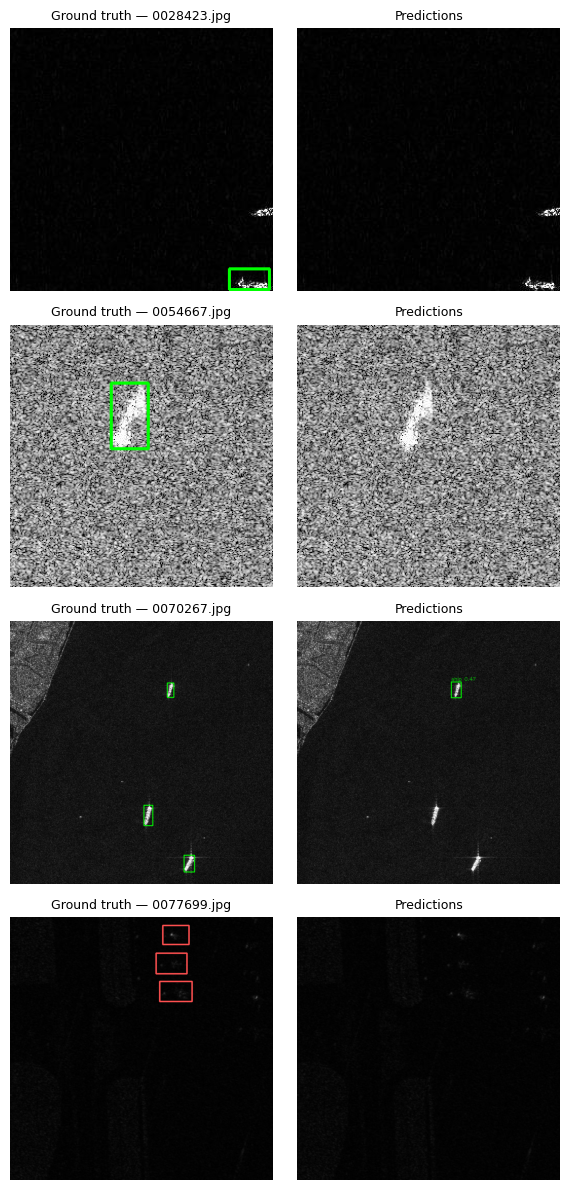

In [15]:
from ultralytics import YOLO
import glob

weights = "/home/user/sar/runs/dryrun_10pct/weights/best.pt"
trained = YOLO(weights)

random.seed(1)
sample_imgs = random.sample(list(VAL_IMG_DIR.iterdir()), 4)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))
for row, img_path in enumerate(sample_imgs):
    # --- Ground truth ---
    img_gt = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img_gt.shape[:2]
    lbl_path = VAL_LBL_DIR / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            cls, cx, cy, bw, bh = line.split()
            cls = int(cls)
            cx, cy, bw, bh = float(cx)*w, float(cy)*h, float(bw)*w, float(bh)*h
            x1, y1 = int(cx - bw/2), int(cy - bh/2)
            x2, y2 = int(cx + bw/2), int(cy + bh/2)
            cv2.rectangle(img_gt, (x1, y1), (x2, y2), COLORS[cls], 2)
    axes[row, 0].imshow(img_gt)
    axes[row, 0].set_title(f"Ground truth — {img_path.name}", fontsize=9)
    axes[row, 0].axis("off")

    # --- Predictions ---
    pred = trained.predict(str(img_path), imgsz=320, verbose=False, conf=0.25)[0]
    img_pr = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    for box in pred.boxes:
        cls = int(box.cls.item())
        conf = float(box.conf.item())
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        cv2.rectangle(img_pr, (x1, y1), (x2, y2), COLORS[cls], 2)
        cv2.putText(img_pr, f"{CLASS_NAMES[cls]} {conf:.2f}",
                    (x1, max(y1-4, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORS[cls], 1)
    axes[row, 1].imshow(img_pr)
    axes[row, 1].set_title("Predictions", fontsize=9)
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()